# Veterinary Clinical Intelligence — Companion Animal Dataset

## Introduction

This project combines veterinary domain expertise with data analytics to explore clinical patterns in companion animal medicine. The dataset consists of **~15,000 synthetic records** for dogs and cats, generated using published prevalence statistics from **VetCompass UK** (n=22,333 dogs; n=142,576 cats) and **SAVSNET**, covering 6 dog breeds and 5 cat breeds across a two-year period (2023–2024).

The data was intentionally seeded with **9 types of clinical data quality errors** — including impossible ages, breed-diagnosis mismatches, and sex-diagnosis conflicts — to simulate the kind of domain-specific issues that appear in real veterinary practice management systems. Identifying and resolving these errors requires veterinary knowledge that goes beyond standard data cleaning techniques.

The analysis is structured in three parts:

- **Part A** — Data loading and initial exploration  
- **Part B** — Domain-expert data cleaning (9 error types)  
- **Part C** — Exploratory data analysis with visualizations

**Tools:** Python · pandas · matplotlib · seaborn   
**Dataset:** Synthetic, parameterized from VetCompass/SAVSNET prevalence data 

## Part A — Load & Explore

In [1022]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1023]:
# Style
plt.style.use('seaborn-v0_8-whitegrid')

# Defaults
plt.rcParams['figure.figsize'] = (9, 5)   
plt.rcParams['font.size'] = 11       

# Color palette
COLOR_PRIMARY = '#4A7C59'    
COLOR_SECONDARY = '#8B5E3C'  
COLOR_TERTIARY = '#F2A65A'   

In [1024]:
df = pd.read_csv("veterinary_clinical_data.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   animal_id             15000 non-null  object 
 1   species               15000 non-null  object 
 2   breed                 15000 non-null  object 
 3   age_years             15000 non-null  float64
 4   weight_kg             15000 non-null  float64
 5   sex                   15000 non-null  object 
 6   visit_id              15000 non-null  object 
 7   visit_date            15000 non-null  object 
 8   presenting_complaint  15000 non-null  object 
 9   body_system           15000 non-null  object 
 10  diagnosis             14969 non-null  object 
 11  severity              15000 non-null  object 
 12  treatment_type        15000 non-null  object 
 13  treatment_detail      14962 non-null  object 
 14  outcome               14961 non-null  object 
dtypes: float64(2), obje

,age_years,weight_kg
count,15000.000000,15000.000000
mean,8.575193,12.090900
std,4.938578,12.057835
min,1.000000,0.100000
25%,4.600000,4.000000
50%,8.100000,5.900000
75%,12.000000,13.700000
max,35.000000,119.000000


In [1025]:
df.isnull().sum()

animal_id                0
species                  0
breed                    0
age_years                0
weight_kg                0
sex                      0
visit_id                 0
visit_date               0
presenting_complaint     0
body_system              0
diagnosis               31
severity                 0
treatment_type           0
treatment_detail        38
outcome                 39
dtype: int64

The dataset contains **15,000 records and 15 columns** — 2 numeric (`age_years`, `weight_kg`) 
and 13 categorical. 

`df.describe()` immediately flags suspicious values: a minimum weight of 0.1 kg and maximum 
of 119 kg, and a maximum age of 35 years — all biologically impossible for the breeds in this 
dataset. These will be addressed in Part B.

`df.isnull().sum()` shows missing values in three columns: `diagnosis` (31), `treatment_detail` 
(38), and `outcome` (39). All other columns are complete.

## Part B — Data Cleaning

### B1 — Missing Values

In [1026]:
df.isnull().any(axis=1).sum()

108

In [1027]:
df = df.dropna()
len(df)

14892

Dropped 108 records with missing values in `diagnosis`, `treatment_detail`, and `outcome` (< 1% of the dataset). These records cannot be used for analysis without key clinical fields.

### B2 — Impossible Ages

In [1028]:
len(df[((df["age_years"] > 20) & (df["species"] == "Dog")) | ((df["age_years"] > 25) & (df["species"] == "Cat"))])

109

In [1029]:
df = df[~(((df["age_years"] > 20) & (df["species"] == "Dog")) | ((df["age_years"] > 25) & (df["species"] == "Cat")))]
len(df)

14783

Removed 109 records with biologically impossible ages: dogs older than 20 years and cats older than 25 years. The maximum recorded lifespan for dogs is ~20 years and for cats ~25 years.

### B3 — Weight outliers

In [1030]:
len(df[(df["weight_kg"] <= 1) | (df["weight_kg"] >= 50)])

102

In [1031]:
df = df[(df["weight_kg"] > 1) & (df["weight_kg"] < 50)]
len(df)

14681

Removed 102 records with biologically impossible weights: below 1 kg and above 50 kg. The lightest breed in the dataset (Chihuahua) weighs a minimum of 1.5 kg at adult age, and the heaviest (German Shepherd) reaches a maximum of 40 kg.

### B4 — Breed-Diagnosis Mismatches

In [1032]:
len(df[(df["breed"] != "French Bulldog") & (df["diagnosis"] == "Brachycephalic Obstructive Airway Syndrome (BOAS)")])

45

In [1033]:
df = df[~((df["breed"] != "French Bulldog") & (df["diagnosis"] == "Brachycephalic Obstructive Airway Syndrome (BOAS)"))]
len(df)

14636

Removed 45 records where Brachycephalic Obstructive Airway Syndrome (BOAS) was diagnosed in non-brachycephalic breeds. BOAS is an anatomical condition caused by the shortened skull structure of brachycephalic breeds. In this dataset, only the French Bulldog is brachycephalic — a diagnosis of BOAS in a Labrador Retriever, German Shepherd, or Beagle is clinically impossible.

### B5 — Sex-diagnosis conflicts

In [1034]:
len(df[(df["diagnosis"] == "Pyometra") & (df["sex"] != "F")])

159

In [1035]:
df = df[~((df["diagnosis"] == "Pyometra") & (df["sex"] != "F"))]
len(df)

14477

Removed 159 records where pyometra was diagnosed in male or spayed female animals. Pyometra is an infection of the uterus and can only occur in intact females (sex = F). Diagnosis in males (M, MN) or spayed females (FS) is clinically impossible.

###  B6 — Species-specific impossibilities

In [1036]:
len(df[(df["diagnosis"] == "Feline Lower Urinary Tract Disease (FLUTD)") & (df["species"] == "Dog")])

56

In [1037]:
df = df[~((df["diagnosis"] == "Feline Lower Urinary Tract Disease (FLUTD)") & (df["species"] == "Dog"))]
len(df)

14421

Removed 56 records where Feline Lower Urinary Tract Disease (FLUTD) was diagnosed in dogs. FLUTD is a feline-specific condition referring to disorders affecting the bladder and urethra of cats. It has no equivalent diagnosis in canine medicine and cannot appear in a dog's clinical record.

###  B7 — Treatment-diagnosis mismatches

In [1038]:
len(df[(df["diagnosis"] == "Fracture") & (df["treatment_detail"] == "Insulin glargine")])

108

In [1039]:
df = df[~((df["diagnosis"] == "Fracture") & (df["treatment_detail"] == "Insulin glargine"))]
len(df)

14313

Removed 108 records where insulin glargine was prescribed for a fracture. Insulin glargine is a long-acting insulin used to manage diabetes mellitus — it has no clinical indication in fracture management. This is a clear treatment-diagnosis mismatch detectable only with domain knowledge.

### B8 — Duplicate breed entries

In [1040]:
df["breed"].unique()

array(['British Shorthair', 'Siamese', 'Domestic Shorthair', 'Chihuahua',
       'Beagle', 'Labrador Retriever', 'French Bulldog', 'Persian',
       'Yorkshire Terrier', 'Maine Coon', 'German Shepherd', 'Labrador',
       'DSH', 'GSD', 'British SH', 'Yorkie'], dtype=object)

In [1041]:
df["breed"] = df["breed"].replace({"Labrador":"Labrador Retriever", 
                                   "DSH":"Domestic Shorthair", 
                                   "GSD":"German Shepherd", 
                                   "British SH":"British Shorthair", 
                                   "Yorkie":"Yorkshire Terrier"})

In [1042]:
df["breed"].unique()

array(['British Shorthair', 'Siamese', 'Domestic Shorthair', 'Chihuahua',
       'Beagle', 'Labrador Retriever', 'French Bulldog', 'Persian',
       'Yorkshire Terrier', 'Maine Coon', 'German Shepherd'], dtype=object)

Standardised breed names by replacing informal aliases with their correct clinical names: "Labrador" → "Labrador Retriever", "GSD" → "German Shepherd", "Yorkie" → "Yorkshire Terrier", "DSH" → "Domestic Shorthair", "British SH" → "British Shorthair". Inconsistent naming would cause these breeds to appear as separate categories in any groupby analysis.

###  B9 — Date errors

In [1043]:
df["visit_date"] = pd.to_datetime(df["visit_date"])

In [1044]:
len(df[(df["visit_date"] > "2024-12-31") | (df["visit_date"] < "2023-01-01")])

108

In [1045]:
df = df[~((df["visit_date"] > "2024-12-31") | (df["visit_date"] < "2023-01-01"))]
len(df)

14205

Removed 108 records with visit dates outside the valid range of 2023-01-01 to 2024-12-31. Errors included future dates (beyond 2024) and dates predating the dataset period (before 2023), which in some cases preceded the animal's recorded birth.

In [1046]:
df.isnull().sum()

animal_id               0
species                 0
breed                   0
age_years               0
weight_kg               0
sex                     0
visit_id                0
visit_date              0
presenting_complaint    0
body_system             0
diagnosis               0
severity                0
treatment_type          0
treatment_detail        0
outcome                 0
dtype: int64

### B10 — Cleaning Summary

| Step | Error Type | Records Removed |
|---|---|---|
| B1 | Missing values | 108 |
| B2 | Impossible ages | 109 |
| B3 | Weight outliers | 102 |
| B4 | Breed-diagnosis mismatch (BOAS) | 45 |
| B5 | Sex-diagnosis conflict (pyometra) | 159 |
| B6 | Species-specific impossibility (FLUTD in dogs) | 56 |
| B7 | Treatment-diagnosis mismatch (insulin for fracture) | 108 |
| B8 | Duplicate breed entries | 0 removed, corrected in place |
| B9 | Date errors | 108 |
| **Total** | | **795 records removed** |

Starting dataset: 15,000 records. Clean dataset: 14,205 records (94.7% retained).

## Part C — Exploratory Data Analysis

### Hypotheses

Before exploring the data, the following clinical hypotheses were formulated 
based on published VetCompass prevalence statistics and veterinary domain knowledge:

1. **Dental disease will be the leading diagnosis** across both species, consistent 
   with VetCompass UK findings where periodontal disease ranks first in companion animal practice.

2. **Breed-specific predispositions will be detectable in the data** — conditions such as 
   BOAS in French Bulldogs, musculoskeletal disease in German Shepherds, and urinary 
   conditions in Persians should appear at higher rates than in the general population.

3. **Outcome will correlate with severity** — severe cases should show higher rates of 
   referral, chronic management, and mortality compared to mild cases.

4. **Chronic and degenerative conditions will skew toward older animals** — urinary, 
   cardiovascular, and dental conditions are expected to present at a higher median age 
   than acute conditions such as ear infections or respiratory disease.

### C1 — Diagnoses by Body System

In [1047]:
body_counts = df["body_system"].value_counts().sort_values()
body_counts

body_system
Reproductive         60
Ophthalmology       540
Cardiovascular      753
Respiratory        1088
Ear                1207
Urinary            1307
Musculoskeletal    1318
Dermatology        1632
GI                 2229
Dental             4071
Name: count, dtype: int64

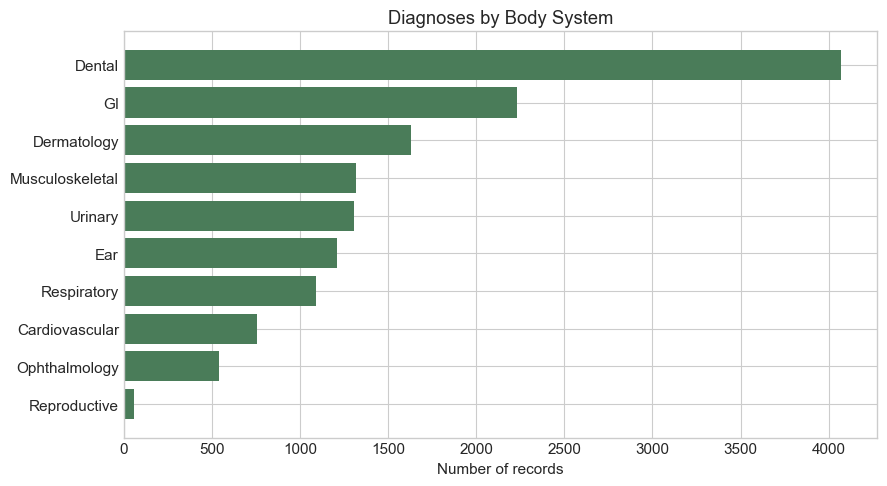

In [1048]:
plt.figure()
plt.barh(body_counts.index, body_counts.values, color=COLOR_PRIMARY)
plt.title("Diagnoses by Body System")
plt.xlabel("Number of records")

plt.tight_layout()
plt.show()

Dental disorders account for the highest number of visits at 4,071 — nearly double the second most common category (GI, 2,229). This reflects published VetCompass findings, where periodontal disease consistently ranks as the leading diagnosis in companion animal practice. Reproductive system disorders are the least common, with only 60 records, consistent with high neutering rates in the companion animal population.

### C2 — Top 10 Most Frequent Diagnoses

In [1049]:
frequent_diagnoses = df["diagnosis"].value_counts().sort_values()
top10 = frequent_diagnoses.head(10)
top10

diagnosis
Intervertebral disc disease (IVDD)      31
Feline Aortic Thromboembolism (FATE)    42
Severe dental disease                   48
Obesity-related GI issues               49
Degenerative myelopathy                 50
Portosystemic shunt (PSS)               52
Pyometra                                60
Mediastinal lymphoma                    80
Patellar luxation                       86
Obesity and Type II Diabetes            86
Name: count, dtype: int64

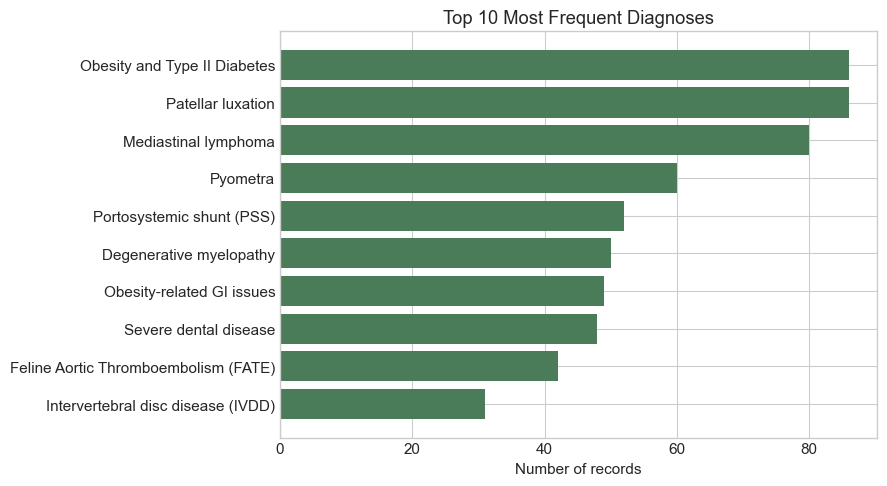

In [1050]:
plt.figure()
plt.barh(top10.index, top10.values, color=COLOR_PRIMARY)
plt.title("Top 10 Most Frequent Diagnoses")
plt.xlabel("Number of records")

plt.tight_layout()
plt.show()

Periodontal disease is the clear leader with 4,023 records, consistent with the body system overview in C1. GI conditions collectively rank high, with vomiting and diarrhoea both appearing in the top 5 — reflecting their high presentation rate in general practice. Notably, two feline-specific conditions appear in the top 10: Feline Lower Urinary Tract Disease (FLUTD, 503 records) and Hypertrophic cardiomyopathy (HCM, 410 records), indicating that cats in this dataset have a disproportionately high representation of chronic and serious conditions relative to their population share.

### C3 — Diagnoses by Species

In [1051]:
dogs = df[df["species"] == "Dog"]
cats = df[df["species"] == "Cat"]

In [1052]:
top10_dogs = dogs["diagnosis"].value_counts().head(10).sort_values()
top10_cats = cats["diagnosis"].value_counts().head(10).sort_values()

In [1053]:
top10_dogs

diagnosis
Hip dysplasia                                         224
Brachycephalic Obstructive Airway Syndrome (BOAS)     248
Kennel cough (CIRD)                                   253
Vomiting (acute)                                      409
Atopic dermatitis                                     410
Pyoderma                                              460
Osteoarthritis                                        477
Diarrhoea / Gastroenteritis                           508
Otitis externa                                       1207
Periodontal disease                                  1790
Name: count, dtype: int64

In [1054]:
top10_cats

diagnosis
Osteoarthritis                                 231
Polycystic Kidney Disease (PKD)                250
Upper respiratory infection (cat flu)          292
Chronic Kidney Disease (CKD)                   360
Diarrhoea / Gastroenteritis                    371
Hypertrophic cardiomyopathy (HCM)              410
Feline Lower Urinary Tract Disease (FLUTD)     503
Vomiting (acute)                               509
Flea allergy dermatitis                        669
Periodontal disease                           2233
Name: count, dtype: int64

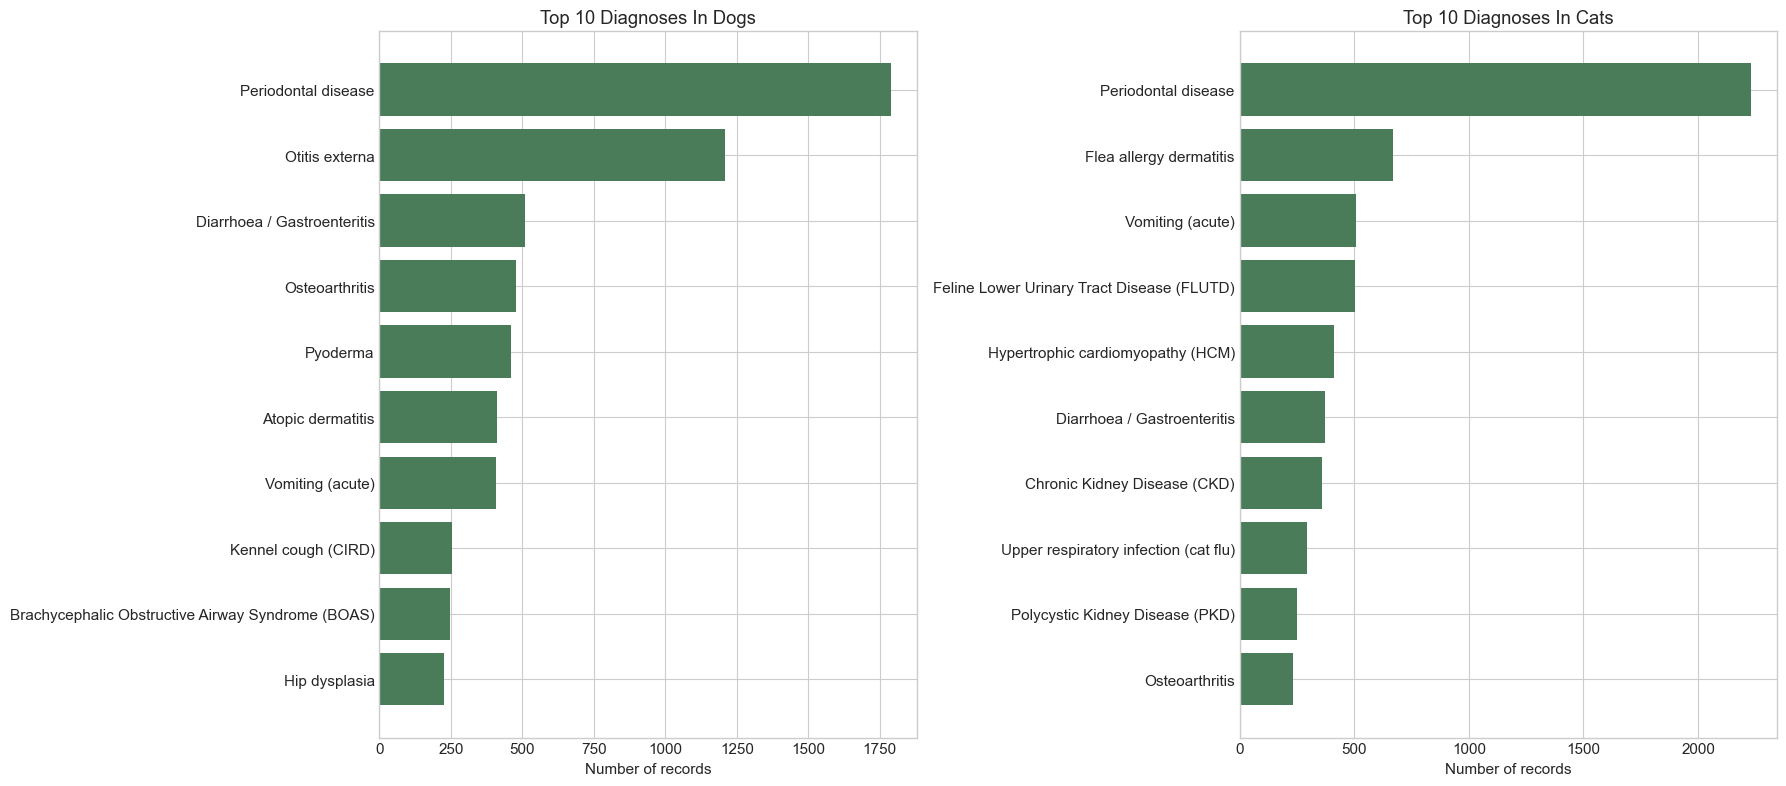

In [1055]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(top10_dogs.index, top10_dogs.values, color=COLOR_PRIMARY)
ax1.set_title("Top 10 Diagnoses In Dogs")
ax1.set_xlabel("Number of records")

ax2.barh(top10_cats.index, top10_cats.values, color=COLOR_PRIMARY)
ax2.set_title("Top 10 Diagnoses In Cats")
ax2.set_xlabel("Number of records")

plt.tight_layout()
plt.show()

Periodontal disease ranks first in both species, though it is notably more prevalent in cats (2,233 records) than in dogs (1,790 records). The dogs' top 10 is dominated by acute and infectious conditions — otitis externa, diarrhoea, vomiting, and pyoderma — none of which appear in the cat top 10. Cats, by contrast, show a higher burden of serious chronic and organ-specific disease: four feline-specific conditions (FLUTD, HCM, CKD, and PKD) appear in their top 10, reflecting the tendency of cats to present with systemic and degenerative conditions as they age.

### C4 — Outcomes by Severity

In [1056]:
df.groupby("severity")["outcome"].value_counts()

severity  outcome           
mild      recovered             5903
          chronic management      62
          improving               11
moderate  recovered             3949
          chronic management    2427
          improving               11
severe    chronic management     971
          recovered              662
          referred               165
          deceased                44
Name: count, dtype: int64

In [1057]:
severity_outcome = df.groupby("severity")["outcome"].value_counts().unstack(fill_value=0)
severity_outcome

outcome,chronic management,deceased,improving,recovered,referred
severity,,,,,
mild,62,0,11,5903,0
moderate,2427,0,11,3949,0
severe,971,44,0,662,165


In [1058]:
severity_pct = severity_outcome.div(severity_outcome.sum(axis=1), axis=0) * 100

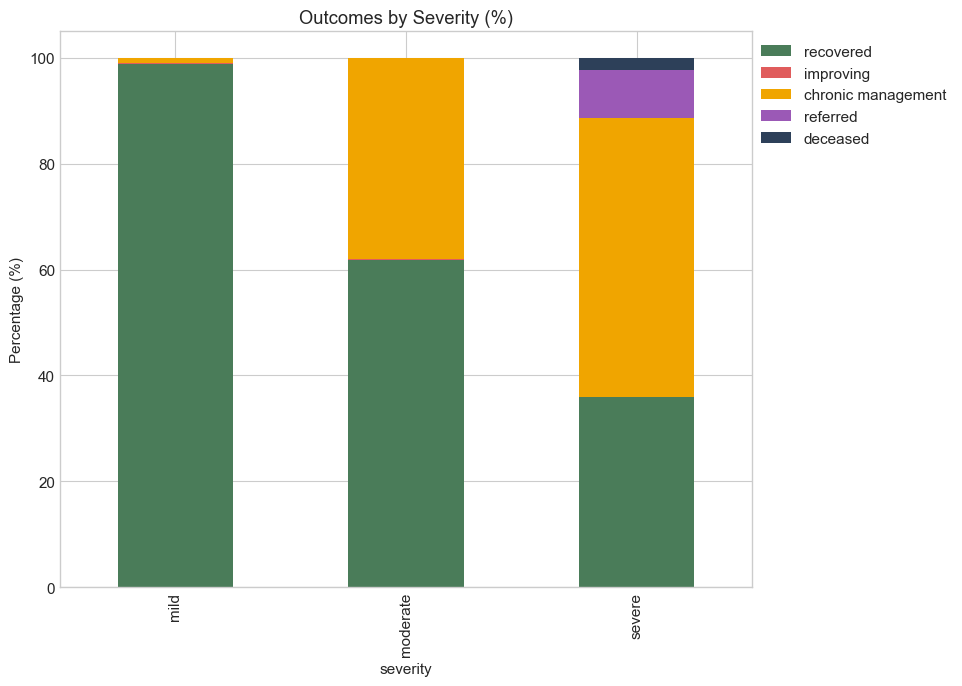

In [1059]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#4A7C59", "#E05C5C", "#F0A500", "#9B59B6", "#2D4059"]
outcome_order = ["recovered", "improving", "chronic management", "referred", "deceased"]
severity_pct = severity_pct[outcome_order]
severity_pct.plot(kind="bar", stacked=True, ax=ax, color=colors)

plt.title("Outcomes by Severity (%)")
plt.ylabel("Percentage (%)")
plt.legend(loc="upper right", bbox_to_anchor=(1.30, 1))
plt.tight_layout()
plt.show()

As severity increases, the proportion of animals that fully recover decreases significantly. Mild cases result in recovery in nearly 100% of visits, with chronic management and other outcomes negligible. Moderate cases show a substantial shift — around 38% require chronic management, reflecting the higher proportion of degenerative conditions such as osteoarthritis and atopic dermatitis at this level. Severe cases show the most complex outcome mix: chronic management accounts for ~53% of records, while referral (9%) and death (2%) appear exclusively at this severity level, consistent with conditions such as degenerative myelopathy, FATE, and mediastinal lymphoma.

### C5 — Top Diagnoses by Breed

In [1060]:
french_bulldog = df[df["breed"] == "French Bulldog"]

In [1061]:
top10_fb = french_bulldog["diagnosis"].value_counts().head(10).sort_values()
top10_fb

diagnosis
Heart murmur (unspecified)                            48
Kennel cough (CIRD)                                   62
Osteoarthritis                                        81
Vomiting (acute)                                      84
Pyoderma                                             100
Diarrhoea / Gastroenteritis                          121
Atopic dermatitis                                    195
Otitis externa                                       236
Brachycephalic Obstructive Airway Syndrome (BOAS)    248
Periodontal disease                                  378
Name: count, dtype: int64

In [1062]:
british_shorthair = df[df["breed"] == "British Shorthair"]

In [1063]:
top10_bs = british_shorthair["diagnosis"].value_counts().head(10).sort_values()
top10_bs

diagnosis
Diarrhoea / Gastroenteritis                    31
Upper respiratory infection (cat flu)          34
Chronic Kidney Disease (CKD)                   42
Feline Aortic Thromboembolism (FATE)           42
Feline Lower Urinary Tract Disease (FLUTD)     47
Vomiting (acute)                               47
Flea allergy dermatitis                        65
Obesity and Type II Diabetes                   86
Hypertrophic cardiomyopathy (HCM)             131
Periodontal disease                           195
Name: count, dtype: int64

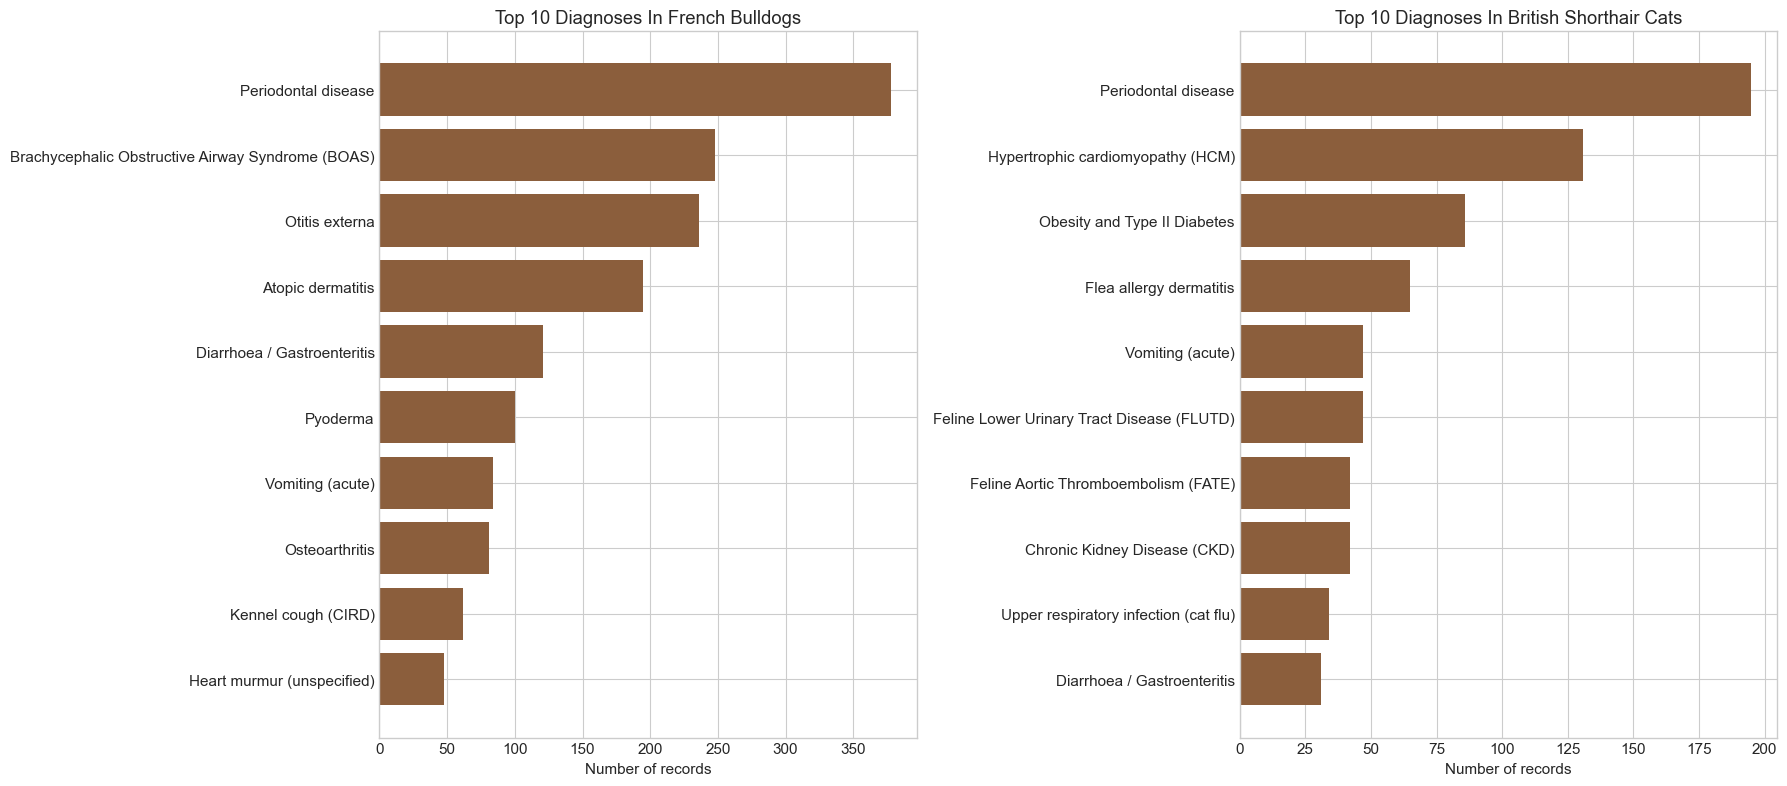

In [1064]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(top10_fb.index, top10_fb.values, color=COLOR_SECONDARY)
ax1.set_title("Top 10 Diagnoses In French Bulldogs")
ax1.set_xlabel("Number of records")

ax2.barh(top10_bs.index, top10_bs.values, color=COLOR_SECONDARY)
ax2.set_title("Top 10 Diagnoses In British Shorthair Cats")
ax2.set_xlabel("Number of records")

plt.tight_layout()
plt.show()

Periodontal disease leads in both breeds, reinforcing the pattern observed across the full dataset in C1 and C2. Beyond that, the breed-specific signal is clear: BOAS ranks second in French Bulldogs and atopic dermatitis fourth — both conditions directly linked to the breed's brachycephalic anatomy and genetic predisposition to skin hypersensitivity. In British Shorthair cats, three breed-specific conditions appear in the top 10: HCM (2nd), obesity and Type II diabetes (3rd), and Feline Aortic Thromboembolism (8th). FATE is particularly notable — it is a life-threatening complication of HCM, and its presence in the top 10 reflects the cardiovascular disease burden that is well-documented in this breed.

### C6 — Breed × Body System Heatmap

Each cell shows what percentage of that breed's total visits fall into each body system. 
Normalising by breed (rather than using raw counts) corrects for the fact that some breeds 
have far more records than others, making patterns genuinely comparable across breeds.

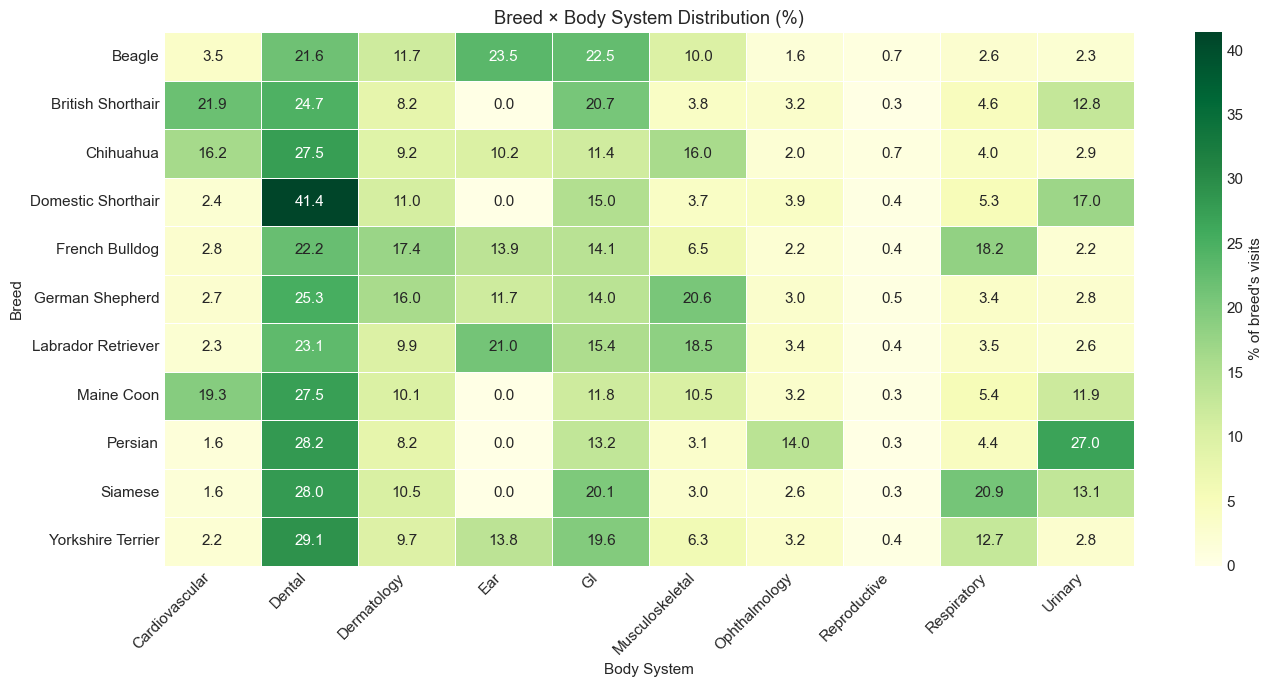

In [1065]:
heatmap_data = df.groupby(["breed", "body_system"]).size().unstack(fill_value=0)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_pct, annot=True, fmt=".1f", cmap="YlGn",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% of breed's visits"})
plt.title("Breed × Body System Distribution (%)")
plt.xlabel("Body System")
plt.ylabel("Breed")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observations

Dental disease dominates across all breeds, consistent with VetCompass prevalence data.
Breed-specific predispositions are clearly visible in the distribution:

- **Domestic Shorthair (41.4% dental)** — highest dental cell in the chart; DSH has no breed-specific predispositions, so dental disease dominates by default
- **French Bulldog (18.2% respiratory)** — elevated vs all other breeds, expected for a brachycephalic breed
- **German Shepherd (20.6% musculoskeletal)** — reflects hip dysplasia and degenerative myelopathy predispositions
- **Persian (27% urinary)** — highest urinary column, consistent with polycystic kidney disease (PKD)
- **British Shorthair (12.8% urinary)** — also elevated, consistent with HCM and FATE predispositions
- **Cat breeds show 0.0% in the ear column** — clinically expected, as otitis externa is predominantly a canine condition

### C7 — Age at Presentation by Body System

Box plots show the distribution of patient age at the time of each visit, grouped by body 
system and ordered by median age. This reveals which conditions tend to present in younger 
animals versus which accumulate over a lifetime — a pattern well-documented in VetCompass 
longitudinal studies.

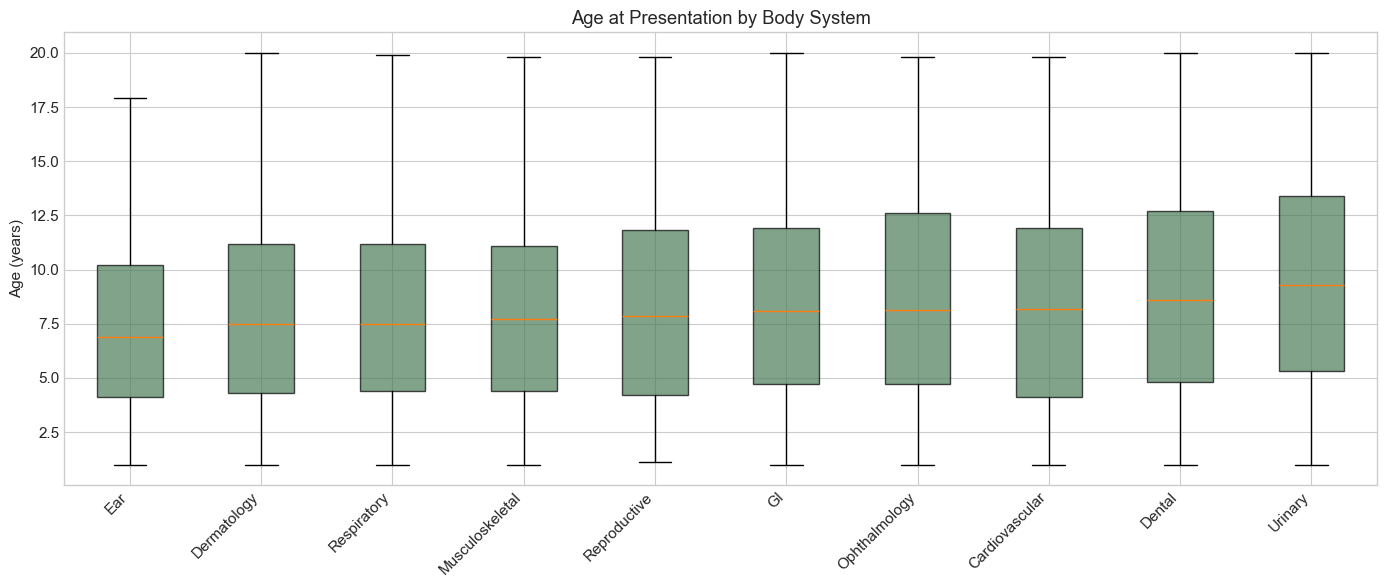

In [1066]:
# Order body systems by median age (youngest → oldest presenting)
body_systems = df.groupby("body_system")["age_years"].median().sort_values().index.tolist()
data_by_system = [df[df["body_system"] == s]["age_years"].values for s in body_systems]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data_by_system, patch_artist=True)

for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_PRIMARY)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(body_systems) + 1))
ax.set_xticklabels(body_systems, rotation=45, ha="right")
ax.set_title("Age at Presentation by Body System")
ax.set_ylabel("Age (years)")
plt.tight_layout()
plt.show()

### Observations

Body systems are ordered left to right by median age at presentation, revealing which 
conditions tend to appear earlier in life versus those that accumulate over time.

- **Ear (youngest median)** — otitis externa is most common in young dogs, particularly floppy-eared breeds such as Beagles
- **Urinary (oldest median + highest Q3)** — driven by CKD in older cats and FLUTD accumulating over time
- **Dental skews older** — periodontal disease is chronic and progressive, building up with age across both species
- **Reproductive shows a wide IQR** — pyometra can occur across a broad age range in intact females, so the spread is clinically expected
- **Boxes overlap significantly across all systems** — conditions do not follow rigid age rules; this reflects real practice, where young animals present with dental disease and senior animals with acute ear infections

## Conclusions

This analysis explored a synthetic companion animal dataset of 15,000 records, 
parameterised from published VetCompass and SAVSNET prevalence statistics across 
6 dog breeds and 5 cat breeds.

**Data cleaning (Part B)** removed 795 records (5.3%) across 9 error types. Several 
of these — breed-diagnosis mismatches, sex-diagnosis conflicts, and species-specific 
impossibilities — could only be identified using veterinary domain knowledge, 
demonstrating that clinical expertise is a prerequisite for meaningful data quality 
work in this field.

**Exploratory analysis (Part C)** revealed several patterns consistent with real-world 
veterinary epidemiology:

- Dental disease is the leading diagnosis across all breeds and both species, 
  consistent with VetCompass UK findings
- Breed-specific predispositions are detectable in the data — French Bulldog 
  respiratory burden, German Shepherd musculoskeletal load, and Persian urinary 
  prevalence all align with published clinical literature
- Urinary and dental conditions skew toward older animals, while ear and dermatology 
  cases present earlier in life
- The breed × body system heatmap confirms that normalising by breed — rather than 
  using raw counts — is essential for meaningful cross-breed comparison

The synthetic nature of the dataset limits the strength of conclusions, but the 
design intentionally mirrors the structure and error patterns found in real practice 
management systems, making it a valid demonstration of domain-expert data analytics 
in a veterinary context.